In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not load image at: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
    return img


In [3]:
def add_gaussian_noise(image, mean=0, sigma=25):
    """
    Adds Gaussian (random normal) noise to an image.
    mean  : mean of the noise distribution (usually 0)
    sigma : standard deviation (controls noise intensity)
    """
    gauss = np.random.normal(mean, sigma, image.shape).astype(np.float32)
    noisy_img = image.astype(np.float32) + gauss
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
    return noisy_img


In [4]:
def apply_filters(noisy_image, ksize=5):
    gaussian_blurred = cv2.GaussianBlur(noisy_image, (ksize, ksize), 0)
    median_blurred = cv2.medianBlur(noisy_image, ksize)
    return gaussian_blurred, median_blurred



PSNR (noisy vs original):          20.82 dB
PSNR (Gaussian blur vs original):  29.14 dB
PSNR (Median blur vs original):    28.29 dB


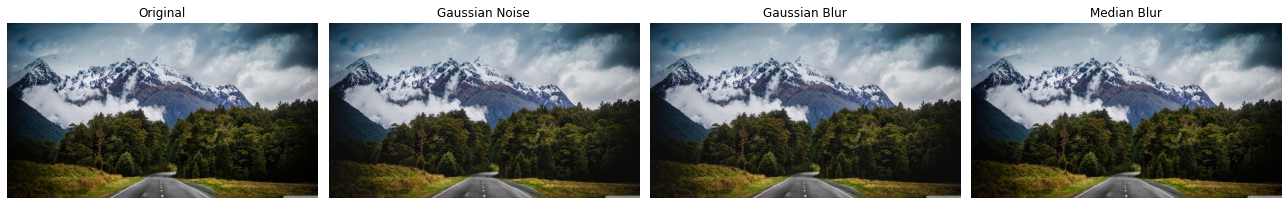

In [5]:
def psnr(original, filtered):
    mse = np.mean((original.astype(np.float32) - filtered.astype(np.float32)) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(255.0 / np.sqrt(mse))


def show_comparison(original, noisy, gaussian_blurred, median_blurred, save_path=None):
    titles = ["Original", "Gaussian Noise", "Gaussian Blur", "Median Blur"]
    images = [original, noisy, gaussian_blurred, median_blurred]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    # ---- Change this to your own image path ----
    image_path = "mountain_road.jpg"

    original = load_image(image_path)
    noisy = add_gaussian_noise(original, mean=0, sigma=25)
    gaussian_blurred, median_blurred = apply_filters(noisy, ksize=5)

    print("PSNR (noisy vs original):          %.2f dB" % psnr(original, noisy))
    print("PSNR (Gaussian blur vs original):  %.2f dB" % psnr(original, gaussian_blurred))
    print("PSNR (Median blur vs original):    %.2f dB" % psnr(original, median_blurred))

    show_comparison(original, noisy, gaussian_blurred, median_blurred,
                     save_path="comparison.png")


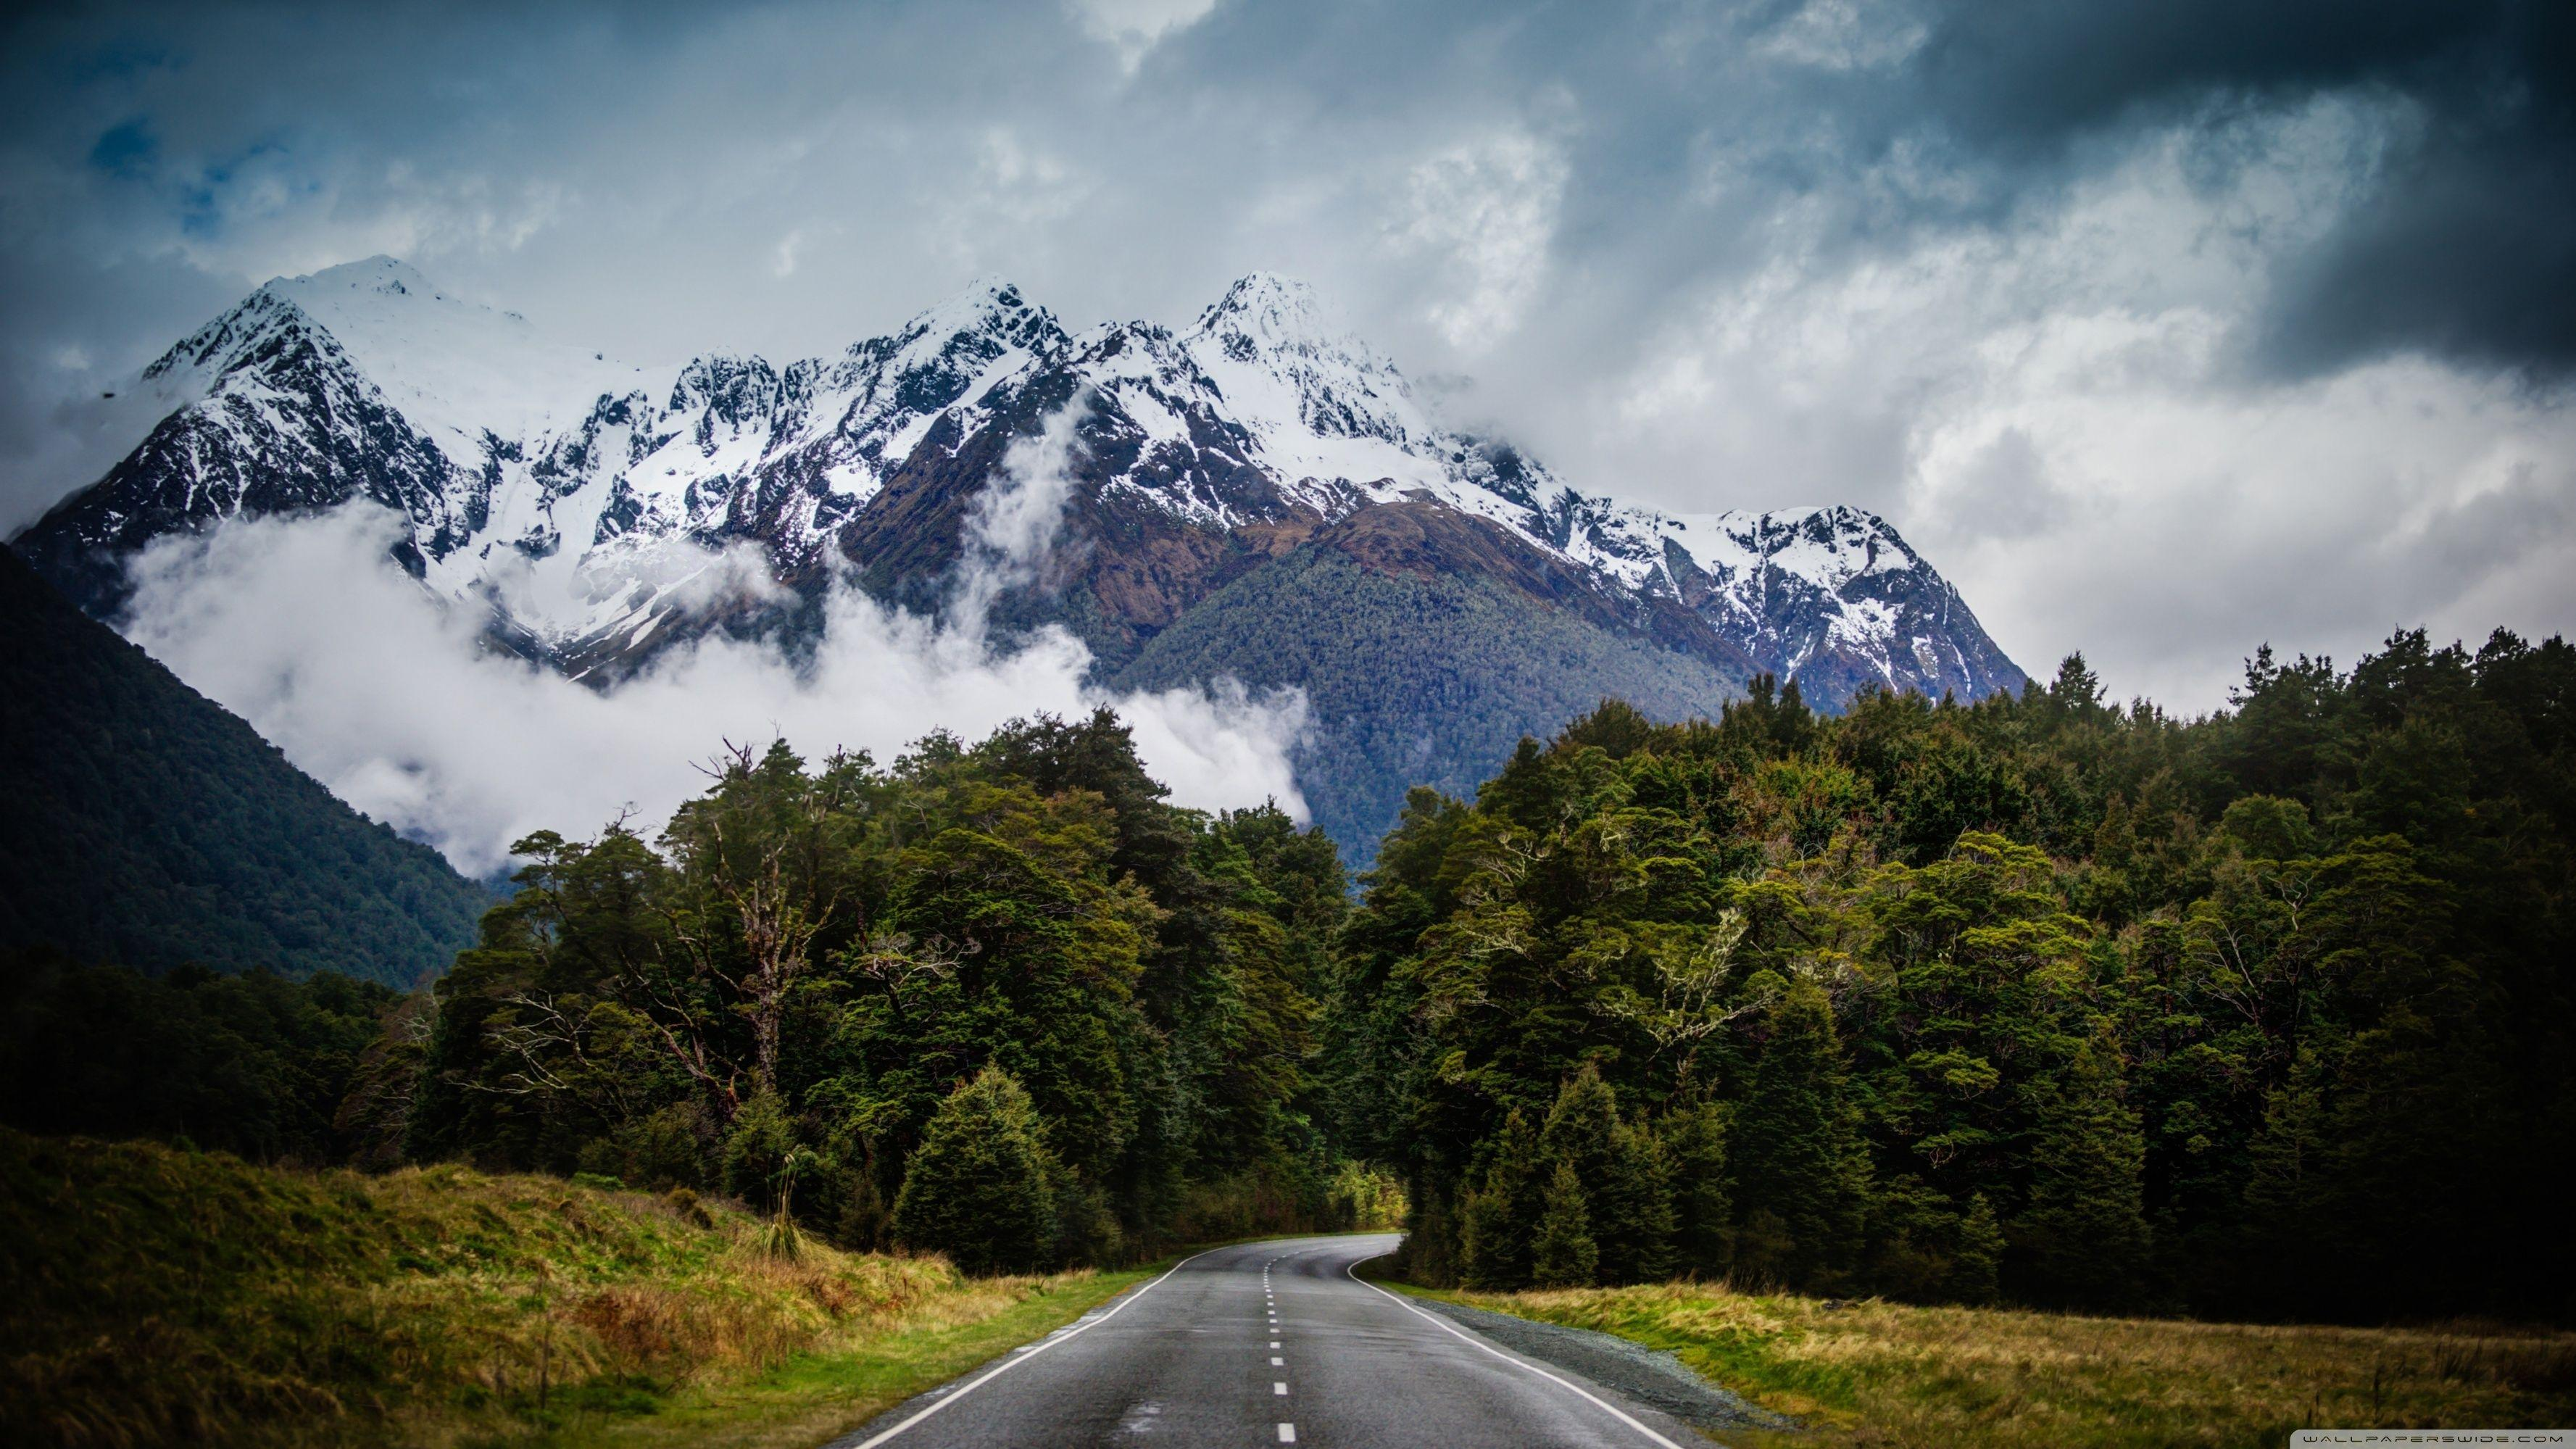

In [6]:
from IPython.display import Image,display 
display(Image("mountain_road.jpg"))